# A Variational Bayesian Inference Technique for Model Updating of Structural Systems with unknown noise statistics

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
# import openseespy.opensees as op
from scipy.linalg import cholesky, inv
import pandas as pd

In [2]:
# Import required OpenSeesPy functions and other modules
from openseespy.opensees import *

In [3]:
%matplotlib inline

## Load Earthquake Data

### Loma Prieta Earthquake

In [4]:
# Load CSV without headers
df = pd.read_csv("quakeData.csv", skiprows=1, header=None)

# Assign column names
df.columns = ["Time", "EastWest", "NorthSouth", "Vertical"]

print(df.tail())

             Time  EastWest  NorthSouth  Vertical
9996   49.985 sec       0.0         0.0       0.0
9997    49.99 sec       0.0         0.0       0.0
9998   49.995 sec       0.0         0.0       0.0
9999       50 sec       0.0         0.0       0.0
10000  50.005 sec       0.0         0.0       0.0


In [5]:
# Eliminar la palabra "sec" y convertir la columna a float
df['Time'] = df['Time'].str.replace(' sec', '')

# Convertir las otras columnas a float (por si acaso)
df['EastWest'] = df['EastWest'].astype(float)
df['NorthSouth'] = df['NorthSouth'].astype(float)
df['Vertical'] = df['Vertical'].astype(float)

In [6]:
print(df.tail())

         Time  EastWest  NorthSouth  Vertical
9996   49.985       0.0         0.0       0.0
9997    49.99       0.0         0.0       0.0
9998   49.995       0.0         0.0       0.0
9999       50       0.0         0.0       0.0
10000  50.005       0.0         0.0       0.0


In [7]:
df["EastWest"] = df["EastWest"]/100
df["NorthSouth"] = df["NorthSouth"]/100
df["Vertical"] = df["Vertical"]/100

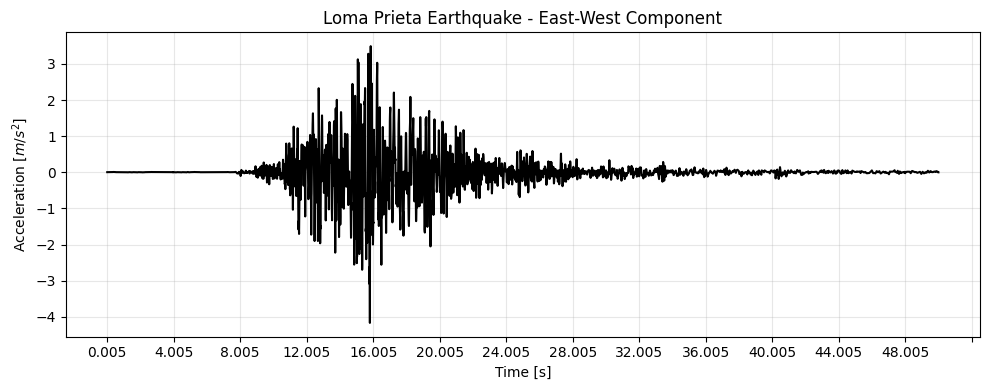

In [8]:
fig1, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(df["Time"], df["EastWest"], color='k')
ax1.set_title("Loma Prieta Earthquake - East-West Component")
ax1.set_xlabel("Time [s]")
ax1.set_ylabel("Acceleration [$m/s^2$]")

# Establecer ticks cada 5 segundos
tick_interval = 5
max_time = df["Time"].max()

# Remove the tick lines
ax1.xaxis.set_major_locator(MaxNLocator(nbins=15))

plt.tight_layout()
plt.grid(visible=True, which='major', alpha=0.3)
plt.minorticks_off()
plt.show()

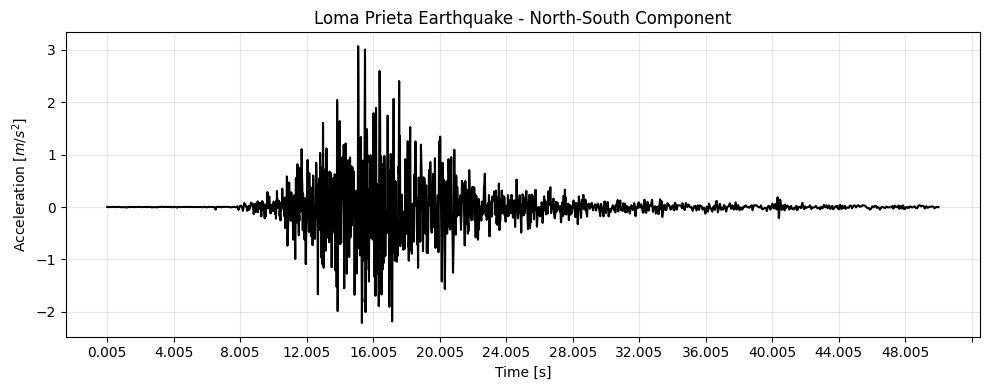

In [9]:
fig2, ax2 = plt.subplots(figsize=(10, 4))
ax2.plot(df["Time"], df["NorthSouth"], color='k')
ax2.set_title("Loma Prieta Earthquake - North-South Component")
ax2.set_xlabel("Time [s]")
ax2.set_ylabel("Acceleration [$m/s^2$]")

# Establecer ticks cada 5 segundos
tick_interval = 5
max_time = df["Time"].max()

# Remove the tick lines
ax2.xaxis.set_major_locator(MaxNLocator(nbins=15))

plt.tight_layout()
plt.grid(visible=True, which='major', alpha=0.3)
plt.minorticks_off()
plt.show()

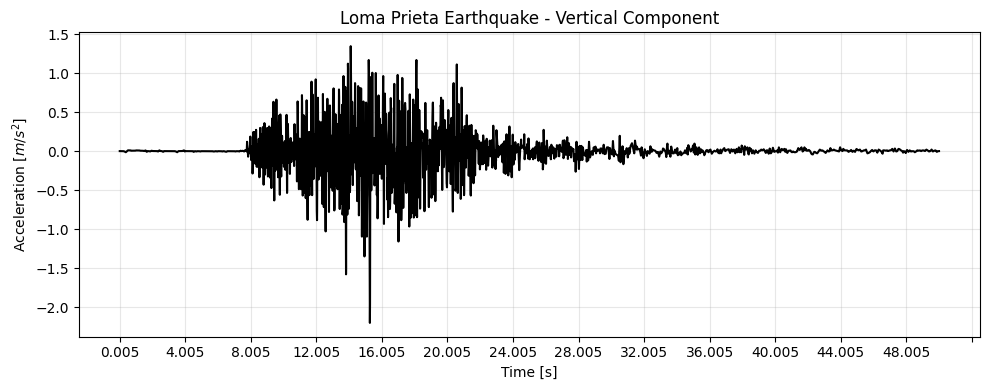

In [10]:
fig3, ax3 = plt.subplots(figsize=(10, 4))
ax3.plot(df["Time"], df["Vertical"], color='k')
ax3.set_title("Loma Prieta Earthquake - Vertical Component")
ax3.set_xlabel("Time [s]")
ax3.set_ylabel("Acceleration [$m/s^2$]")

# Establecer ticks cada 5 segundos
tick_interval = 5
max_time = df["Time"].max()

# Remove the tick lines
ax3.xaxis.set_major_locator(MaxNLocator(nbins=15))

plt.tight_layout()
plt.grid(visible=True, which='major', alpha=0.3)
plt.minorticks_off()
plt.show()

### Convert Pandas Dataframe to Numpy array

In [11]:
df_EastWest = df["EastWest"].to_numpy()
df_NorthSouth = df["NorthSouth"].to_numpy()
df_Vertical = df["Vertical"].to_numpy()

df_Time = df["Time"].to_numpy()

In [12]:
len(df_Time)

10001

## Simulate FE response

In [13]:
# def simulate_true_response(theta_true, time_steps):
def simulate_true_response(theta_true):
    """
    Simulate ground truth FE response with true parameters (e.g., GMP steel material) for a 3-story 1-bay steel moment frame.
    
    The function builds an OpenSees model, applies gravity loads and a Loma Prieta earthquake excitation 
    (read from the df_NorthSouth record), and records the structural response at the top (roof) node.
    It returns a noise-free response (y_true) and a response with added non-stationary noise (y_measured).
    
    Parameters:
      theta_true   : Dictionary or vector of true parameters (e.g., material properties, section sizes).
                     (For simplicity, this script uses assumed GMP steel properties.)
      time_steps   : Array of time points at which the response is recorded.
    
    Returns:
      y_true       : Noise-free time history response of the selected degree of freedom (e.g., horizontal displacement).
      y_measured   : The simulated measured response with added non-stationary noise.
    """
    # -----------------------------------------------------------------------------
    # 1. Model Setup and Gravity Analysis (Building a 3-story 1-bay steel frame)
    # -----------------------------------------------------------------------------
    wipe()  # Clear any existing model
    
    # Create ModelBuilder (with two-dimensions and 3 DOF/node)
    model('basic', '-ndm', 2, '-ndf', 3)
    
    # Define units: Newton, meters, seconds
    g = 9.81  # gravitational acceleration in m/s²
    
    # ---------------------------------------------------------------------------
    # Create a simple 3-story 1-bay steel moment frame model.
    # For illustration purposes, node locations, element connectivity, and masses are defined.
    # In a complete model, these would be based on detailed design/calibration.
    # ----------------------------------------------------------------------------
    
    # Geometry parameters (in meters)
    storyHeight = 3.5    # story height
    bayWidth    = 6.0    # bay width
    
    # Create nodes (3 levels: 1st, 2nd, and 3rd floor)
    # Assuming a simple rectangular frame with nodes at the four corners.
    # For simplicity, assign nodes numbers in a grid fashion:
    #
    #   5 ----- 6   <-- 3rd floor (roof)
    #   |       |
    #   3 ----- 4   <-- 2nd floor
    #   |       |
    #   1 ----- 2   <-- 1st floor / basement
    #
    # Here, we assume that the earthquake excitation is applied at the basement level (nodes 1 & 2).
    node(1, 0.0, 0.0)
    node(2, bayWidth, 0.0)
    node(3, 0.0, storyHeight)
    node(4, bayWidth, storyHeight)
    node(5, 0.0, 2*storyHeight)
    node(6, bayWidth, 2*storyHeight)
    
    # Fix the base nodes in all degrees of freedom
    fix(1, 1, 1, 1)
    fix(2, 1, 1, 1)

    # Define materials for nonlinear columns
    # ------------------------------------------
    # CONCRETE (using typical SI values in MPa and corresponding strains)

    fcc = theta_true.get('fcc', 30e6)
    fcu = theta_true.get('fcu', 25e6)

    # Core concrete (confined): (tag, f'c, ec0, f'cu, ecu)
    uniaxialMaterial('Concrete01', 1, -fcc, -0.002, -(fcc+5e6), -0.006)
    # Cover concrete (unconfined)
    uniaxialMaterial('Concrete01', 2, -fcu, -0.002, -(fcu+5e6), -0.004)
    
    # STEEL: Reinforcing steel in SI
    # Typical values for reinforcing steel: fy ~ 415 MPa, E ~ 210e9 N/m², strain hardening ratio = 0.01
    fy = theta_true.get('fy', 420e6)  # Yield stress in N/m²
    E_steel = theta_true.get('E', 210e9)  # Young's modulus in N/m²
    uniaxialMaterial('Steel01', 3, fy, E_steel, 0.01)

    # Define cross-section for nonlinear columns
    # ------------------------------------------
    
    #  some parameters
    colWidth = 0.25
    colDepth = 0.25
    
    cover = 0.04  # cover thickness in m (~40 mm)
    As = 4*(129/1000**2)      # area of reinforcing bars in m² (4#4)
    
    # some variables derived from the parameters
    y1 = colDepth / 2.0
    z1 = colWidth / 2.0
    
    section('Fiber', 1)
    
    # Create the concrete core fibers
    patch('rect', 1, 10, 1, cover - y1, cover - z1, y1 - cover, z1 - cover)
    
    # Create the concrete cover fibers (top, bottom, left, right)
    patch('rect', 2, 10, 1, -y1, z1 - cover, y1, z1)
    patch('rect', 2, 10, 1, -y1, -z1, y1, cover - z1)
    patch('rect', 2, 2, 1, -y1, cover - z1, cover - y1, z1 - cover)
    patch('rect', 2, 2, 1, y1 - cover, cover - z1, y1, z1 - cover)
    
    # Create the reinforcing fibers (left, middle, right)
    layer('straight', 3, 3, As, y1 - cover, z1 - cover, y1 - cover, cover - z1)
    layer('straight', 3, 2, As, 0.0, z1 - cover, 0.0, cover - z1)
    layer('straight', 3, 3, As, cover - y1, z1 - cover, cover - y1, cover - z1)

    # Define column elements
    # ----------------------
    
    # Geometry of column elements
    #                tag
    
    geomTransf('PDelta', 1)
    
    # Number of integration points along length of element
    np = 5
    
    # Lobatto integratoin
    beamIntegration('Lobatto', 1, 1, np)
    
    # Create the coulumns using Beam-column elements
    #               e            tag ndI ndJ transfTag integrationTag
    eleType = 'forceBeamColumn'
    element(eleType, 1, 1, 3, 1, 1)
    element(eleType, 2, 3, 5, 1, 1)
    element(eleType, 3, 2, 4, 1, 1)
    element(eleType, 4, 4, 6, 1, 1)
    
    #   5 ----- 6   <-- 3rd floor (roof)
    #   |       |
    #   3 ----- 4   <-- 2nd floor
    #   |       |
    #   1 ----- 2   <-- 1st floor / basement
    
    # Define beam element
    # -----------------------------
    
    # Geometry of column elements
    #                tag
    geomTransf('Linear', 2)
    
    # Create the beam element
    #                          tag, ndI, ndJ, A,     E,    Iz, transfTag
    element('elasticBeamColumn', 5, 3, 4, 0.2*0.15, 30e9, 0.3*0.6**3/24, 2)
    element('elasticBeamColumn', 6, 5, 6, 0.2*0.15, 30e9, 0.3*0.6**3/24, 2)
    
    # Nominal axial capacity (N):
    # Pn = 0.85 * f_c * (A_g - A_s) + f_y * A_s
    #    = 0.85 * 30e6 * (0.25*0.25 - 4*(π/4*0.0127**2)) + 420e6 * 4*(π/4*0.0127**2)
    #    ≈ 1.794e6  # N
    
    # Define gravity loads
    # --------------------
    
    #  a parameter for the axial load
    P = 180e3*5  # axial load in N (10% of axial capacity of columns)
    
    # Create a Plain load pattern with a Linear TimeSeries
    timeSeries('Linear', 1)
    pattern('Plain', 1, 1)
    
    # Create nodal loads at nodes 3 & 4
    #    nd  FX,  FY, MZ
    load(3, 0.0, -P, 0.0)
    load(4, 0.0, -P, 0.0)
    load(5, 0.0, -P, 0.0)
    load(6, 0.0, -P, 0.0)
    
    # ------------------------------
    # Start of analysis generation
    # ------------------------------
    
    # Create the system of equation, a sparse solver with partial pivoting
    system('BandGeneral')
    
    # Create the constraint handler, the transformation method
    constraints('Transformation')
    
    # Create the DOF numberer, the reverse Cuthill-McKee algorithm
    numberer('RCM')
    
    # Create the convergence test, the norm of the residual with a tolerance of
    # 1e-12 and a max number of iterations of 10
    test('NormDispIncr', 1.0e-12, 10, 3)
    
    # Create the solution algorithm, a Newton-Raphson algorithm
    algorithm('Newton')
    
    # Create the integration scheme, the LoadControl scheme using steps of 0.1
    integrator('LoadControl', 0.1)
    
    # Create the analysis object
    analysis('Static')
    
    # Requires 10 steps to reach the load level
    analyze(10)
    
    # -----------------------------------------------------------------------------
    # Set the gravity loads to be constant & reset the time in the domain
    # -----------------------------------------------------------------------------
    loadConst('-time', 0.0)
    
    # -----------------------------------------------------------------------------
    # End of Model Generation & Initial Gravity Analysis
    # -----------------------------------------------------------------------------
    
    # Define gravitational acceleration and an axial load in SI units
    g = 9.81  # m/s²
    
    # Compute nodal mass from the axial load (mass = load / g) [kg]
    m = P / g
    
    # Assign nodal masses for the roof/upper floor nodes 
    # (assuming these nodes represent the dynamic masses of the system)
    # In this model, nodes 3, 4, 5, and 6 are not fixed and receive a mass assignment.
    mass(3, m, m, 0.0)
    mass(4, m, m, 0.0)
    mass(5, m, m, 0.0)
    mass(6, m, m, 0.0)
    
    nPts = 10000
    dt = 1/200
    
    # Create a Path time series using the ground motion data directly.
    # The '-values' option accepts the array values.
    # Note: In OpenSeesPy, pass the values as a unpacked list.
    timeSeries('Path', 2, '-dt', dt, '-values', *df_NorthSouth.tolist())
    
    # Create a UniformExcitation load pattern in the horizontal (X) direction.
    # The pattern tag is 2, and the direction is 1.
    pattern('UniformExcitation', 2, 1, '-accel', 2)
    
    # -----------------------------------------------------------------------------
    # Set Rayleigh damping factors (assumed here small)
    # -----------------------------------------------------------------------------
    rayleigh(0.0, 0.0, 0.0, 0.000625)
    
    # -----------------------------------------------------------------------------
    # Delete the old analysis objects (but not the model)
    # -----------------------------------------------------------------------------
    wipeAnalysis()
    
    # -----------------------------------------------------------------------------
    # Create analysis objects for transient analysis
    # -----------------------------------------------------------------------------
    system('BandGeneral')
    constraints('Plain')
    test('NormDispIncr', 1.0e-12, 10)
    algorithm('Newton')
    numberer('RCM')
    integrator('Newmark', 0.5, 0.25)
    analysis('Transient')
    
    # Perform an eigenvalue analysis before transient analysis
    numEigen = 2
    eigenValues = eigen(numEigen)
    # print("Eigenvalues at start of transient analysis:", eigenValues)
    
    # -----------------------------------------------------------------------------
    # Transient Analysis Loop: Perform earthquake excitation
    # -----------------------------------------------------------------------------
    tFinal = nPts * dt
    tCurrent = getTime()
    ok = 0
    
    time_record = [tCurrent]
    u6 = [0.0]  # to store horizontal displacement of node 6
    
    while ok == 0 and tCurrent < tFinal:
        # ok = analyze(1, 0.01)  # take one analysis step with 0.01 s time step
        ok = analyze(1, 0.01)  # take one analysis step with 0.01 s time step
        # If the analysis fails, attempt a ModifiedNewton restart
        if ok != 0:
            print("Regular Newton failed at t =", tCurrent, ". Trying ModifiedNewton with initial stiffness.")
            test('NormDispIncr', 1.0e-12, 100, 0)
            algorithm('ModifiedNewton', '-initial')
            ok = analyze(1, 0.01)
            if ok == 0:
                print("ModifiedNewton succeeded; reverting to regular Newton.")
            test('NormDispIncr', 1.0e-12, 10)
            algorithm('Newton')
        tCurrent = getTime()
        time_record.append(tCurrent)
        # Record horizontal displacement (DOF 1) at node 3 in meters.
        u6.append(nodeDisp(6, 1))
    
    # print("Done")

    # return y_true, y_measured
    return time_record, u6

### Clean Response

In [14]:
# Define the true parameter set for the model in SI units.
theta_true = {
    'fcc': 30e6,         # MPa (typical for confined concrete)
    'fcu': 25e6,         # MPa (typical for confined concrete)
    'fy': 420e6,         # MPa (typical for structural steel)
    'E': 210e9,       # MPa (Young's modulus)
}

time_record, y_true = simulate_true_response(theta_true)

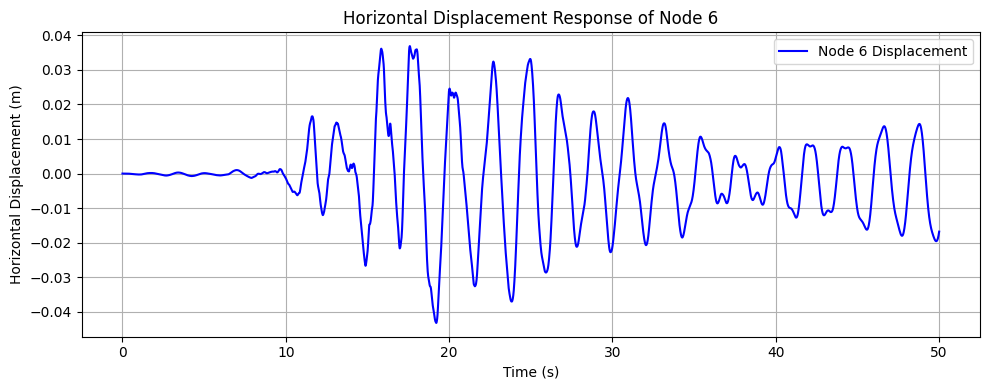

In [15]:
plt.figure(figsize=(10, 4))
plt.plot(time_record, y_true, 'b-', label='Node 6 Displacement')
plt.xlabel('Time (s)')
plt.ylabel('Horizontal Displacement (m)')
plt.title('Horizontal Displacement Response of Node 6')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("==========================")

### Noisy data

In [16]:
# Create a non-stationary noise: variance may vary with time (for example, increasing variance)
# Here we assume a simple time-varying standard deviation, e.g. 5% of the response magnitude multiplied by a factor.
noise_std = 0.001 * (1 + 0.5*np.sin(2*np.pi*np.array(y_true)/max(y_true)))
noise = np.random.normal(0, noise_std)
y_measured = y_true + noise

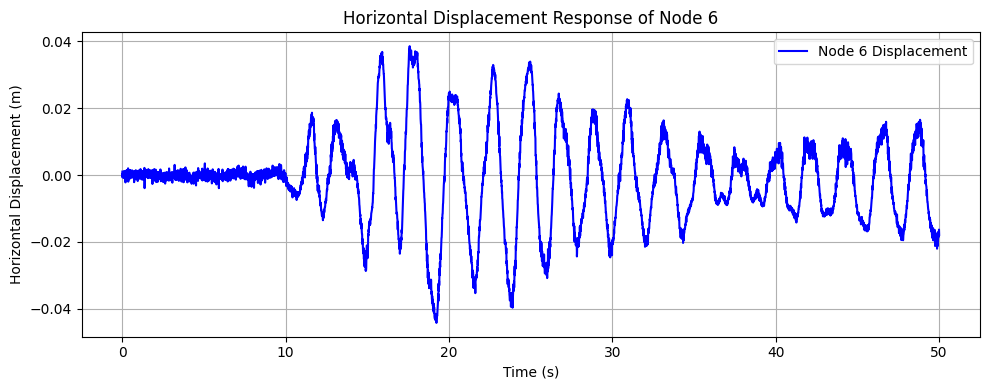

In [17]:
plt.figure(figsize=(10, 4))
plt.plot(time_record, y_measured, 'b-', label='Node 6 Displacement')
plt.xlabel('Time (s)')
plt.ylabel('Horizontal Displacement (m)')
plt.title('Horizontal Displacement Response of Node 6')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("==========================")

## FE Model Wrapper

In [18]:
class FEModel:
    """
    Finite-element wrapper for 3-story 1-bay steel moment frame.
    compute_response(theta) -> response vector h(theta)
    compute_sensitivity(theta) -> sensitivity matrix C = \partial h / \partial theta
    """
    def __init__(self, base_motion):
        self.base_motion = base_motion

    def compute_response(self, theta):
        # Run OpenSees and return array of roof displacement time history
        time_record, u6 = simulate_true_response(theta)
        return np.array(u6)

    def compute_sensitivity(self, theta, eps=1e-4):
        # Finite-difference sensitivity of response w.r.t parameters
        h0 = self.compute_response(theta)
        n = h0.size
        keys = list(theta.keys())
        p = len(keys)
        C = np.zeros((n, p))
        for i, key in enumerate(keys):
            thp = theta.copy(); thm = theta.copy()
            thp[key] += eps; thm[key] -= eps
            hp = self.compute_response(thp)
            hm = self.compute_response(thm)
            C[:, i] = (hp - hm) / (2 * eps)
        return C

<>:2: SyntaxWarning: invalid escape sequence '\p'
<>:2: SyntaxWarning: invalid escape sequence '\p'
C:\Users\odhurtad\AppData\Local\Temp\ipykernel_24008\1412493095.py:2: SyntaxWarning: invalid escape sequence '\p'
  """


## Variational Bayesian Estimator

In [19]:
class VBEstimator:
    """
    Variational Bayesian estimator (adaptive) for model parameters and noise.
    Implements Eqs. (21), (25) from Nabiyan et al. (2023).  
    """
    def __init__(self, theta_init, P_init, mu_init, lambda_init, nu_init, V_init, Q, rho, rho_prime, ny, max_iter=1):
        # model parameters
        self.theta = np.array(list(theta_init.values()))          # (p,)
        self.P = P_init                                           # (p,p)
        # noise stats
        self.mu = mu_init                                         # (ny,)
        self.lambda_ = lambda_init                                # scalar
        self.nu = nu_init                                         # scalar
        self.V = V_init                                           # (ny,ny)
        # process noise covariance
        self.Q = Q                                                # (p,p)
        # forgetting factors
        self.rho = rho                                            
        self.rho_prime = rho_prime                                
        # dimensions
        self.ny = ny                                              
        self.p = self.theta.size
        self.max_iter = max_iter

    def predict_step(self):
        # Eq. (1) dynamics for parameters; forgetting for noise NIW priors
        self.theta_prior = self.theta.copy()
        self.P_prior = self.P + self.Q
        self.mu_prior = self.mu.copy()
        # NIW prior updates
        self.lambda_prior = self.rho_prime * self.lambda_
        self.nu_prior = self.rho * (self.nu - self.ny - 1) + self.ny + 1
        self.V_prior = self.rho * self.V

    def correct_step(self, yk, h_prior, C_prior):
        # yk: measurement at time k (ny,)
        # h_prior: predicted response vector at theta_prior (ny,)
        # C_prior: sensitivity at theta_prior (ny,p)
        # initialize
        theta_post = self.theta_prior.copy()
        # posterior noise cov estimate R_post using NIW mean: Eq. (18)
        R_post = self.V_prior / (self.nu_prior - self.ny - 1)
        mu_post = None

        for _ in range(self.max_iter):
            # Kalman gain: K = Pθy (Pyy)^-1
            Ptheta_y = self.P_prior @ C_prior.T                        # (p,ny)
            Pyy = C_prior @ self.P_prior @ C_prior.T + R_post         # (ny,ny)
            K = Ptheta_y @ inv(Pyy)                                   # (p,ny)
            # update theta
            theta_new = self.theta_prior + K @ (yk - h_prior - self.mu_prior)
            # update noise stats: Eq. (25-a,d) and NIW updates
            mu_new = (self.lambda_prior / (1 + self.lambda_prior)) * self.mu_prior \
                     + (1 / (1 + self.lambda_prior)) * (yk - h_prior)
            # V update: Eq. (25-d)
            term = (yk - h_prior - self.mu_prior)[:,None] @ (yk - h_prior - self.mu_prior)[None,:]
            V_new = self.V_prior + (self.lambda_prior / (1 + self.lambda_prior)) * term \
                    + C_prior @ self.P_prior @ C_prior.T
            R_new = V_new / (self.nu_prior + 1 - self.ny - 1)
            # convergence check
            if np.linalg.norm(theta_new - theta_post)/np.linalg.norm(theta_post) < 1e-2 \
               and np.linalg.norm(R_new - R_post)/np.linalg.norm(R_post) < 1e-2:
                mu_post = mu_new; R_post = R_new; theta_post = theta_new; break
            # otherwise iterate
            mu_post = mu_new; R_post = R_new; theta_post = theta_new

        # posterior updates: Eq. (21-b)
        P_post = self.P_prior - K @ Pyy @ K.T
        # assign posterior to state
        self.theta = theta_post
        self.P = P_post
        self.mu = mu_post
        self.V = V_new
        self.lambda_ = self.lambda_prior + 1
        self.nu = self.nu_prior + 1

## Main Workflow

In [20]:
# -----------------------------------------------------------------------------
# Example integration of VBEstimator with FEModel and measurements
# -----------------------------------------------------------------------------
# Prepare FEModel
fe = FEModel(base_motion=df_NorthSouth)
# Initial hyperparameters (from paper Sec.5 Case 1)

theta0 = {
    'fcc': 30e6*0.8,         # MPa (typical for confined concrete)
    'fcu': 25e6*0.8,         # MPa (typical for confined concrete)
    'fy': 420e6*0.8,         # MPa (typical for structural steel)
    'E': 210e9*0.8,       # MPa (Young's modulus)
}

P0 = np.diag((0.2 * np.array(list(theta0.values())))**2)
mu0 = np.zeros(1)        # single-output case: ny=1
lambda0 = 1.0
nu0 = 2.1               # > ny+1 = 2
V0 = (nu0 - 1 - 1) * np.eye(1) * 1e-5  # V0 = (v0-ny-1) * R0
Q = np.diag((1e-4 * np.array(list(theta0.values())))**2)
rho, rho_p = 0.95, 0.95
ny = 1
vb = VBEstimator(theta0, P0, mu0, lambda0, nu0, V0, Q, rho, rho_p, ny)

# Simulate true response and noisy measurements
time_record, y_true = simulate_true_response(theta_true)
noise_std = 0.001 * (1 + 0.5 * np.sin(2 * np.pi * np.array(y_true)/max(y_true)))
y_meas = np.array(y_true) + np.random.normal(0, noise_std)

In [22]:
# Histories for diagnostics

J_history = []
theta_history = []
mu_history = []            # will store vb.mu (shape ny,)
R_history = []             # will store R_k (shape ny×ny)
time_steps = time_record   # use the time vector from your first simulate_true_response

# Recursive estimation loop
for k in range(len(y_meas)):
    vb.predict_step()
    # predicted response and sensitivity
    h_all = fe.compute_response(dict(zip(theta0.keys(), vb.theta_prior)))
    C_all = fe.compute_sensitivity(dict(zip(theta0.keys(), vb.theta_prior)))
    h_k = np.array([h_all[k]])
    C_k = C_all[k:k+1, :]
    resid = y_meas[k] - h_k - vb.mu_prior
    J_history.append((resid**2).item())

    # ――― do the correction and then record the posterior noise‐stats ―――
    vb.correct_step(np.array([y_meas[k]]), h_k, C_k)

    # record the posterior mean vector μₖ
    mu_history.append(vb.mu.copy())

    # reconstruct the posterior covariance Rₖ from the NIW parameters:
    #  R_k = V / (ν − n_y − 1)
    Rk = vb.V / (vb.nu - vb.ny - 1)
    R_history.append(Rk.copy())

    theta_history.append(vb.theta.copy())
# ――― end of loop ―――

In [23]:
# Final estimates
theta_keys = list(theta0.keys())
print("Final estimated parameters:")
for key, val in zip(theta_keys, vb.theta):
    print(f"  {key}: {val:.4e}")

Final estimated parameters:
  fcc: 1.4856e+07
  fcu: 3.3215e+07
  fy: 3.2509e+08
  E: 1.8341e+11


## Validation & Visualization

In [24]:
# convert to arrays
mu_history = np.vstack(mu_history)       # shape (N, ny)
R_history = np.stack(R_history, axis=0)  # shape (N, ny, ny)

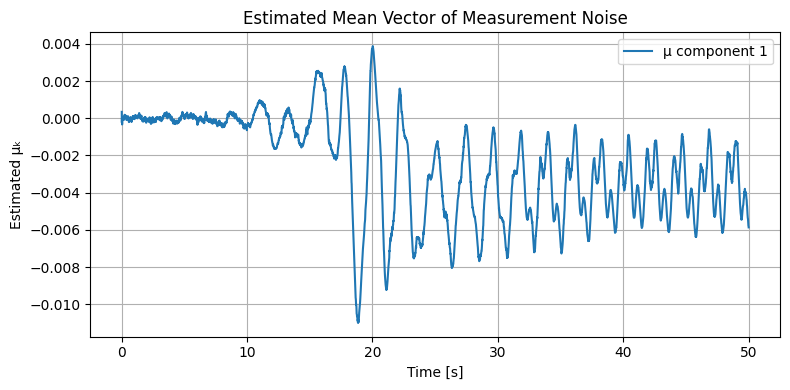

In [27]:
# Plot each component of the mean vector μₖ over time
fig, ax = plt.subplots(figsize=(8,4))
for i in range(mu_history.shape[1]):
    ax.plot(time_steps, mu_history[:,i], label=f'μ component {i+1}')
ax.set_xlabel('Time [s]')
ax.set_ylabel('Estimated μₖ')
ax.set_title('Estimated Mean Vector of Measurement Noise')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

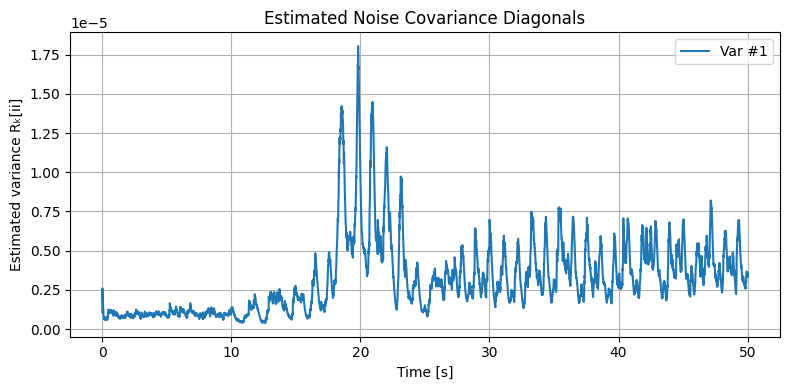

In [30]:
# Plot each diagonal entry of Rₖ over time (variance of each sensor)
fig, ax = plt.subplots(figsize=(8,4))
for i in range(R_history.shape[1]):
    ax.plot(time_steps, R_history[:,i,i], label=f'Var #{i+1}')
ax.set_xlabel('Time [s]')
ax.set_ylabel('Estimated variance Rₖ[{}]'.format('ii'))
ax.set_title('Estimated Noise Covariance Diagonals')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

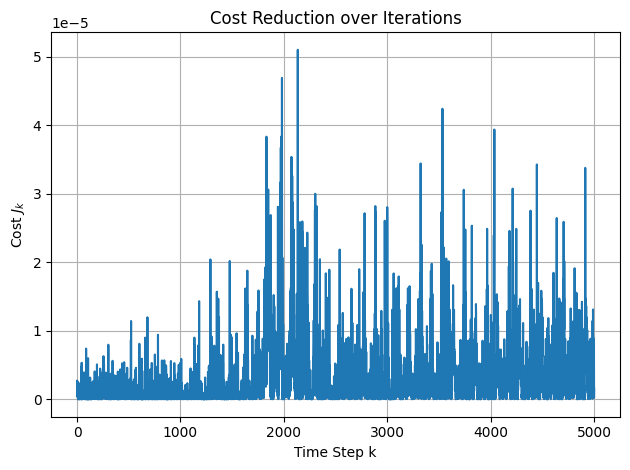

In [31]:
# Plot cost history to show reduction of J over time
plt.figure()
plt.plot(J_history)
plt.xlabel('Time Step k')
plt.ylabel('Cost $J_k$')
plt.title('Cost Reduction over Iterations')
plt.grid(True)
plt.tight_layout()
plt.show()

In [32]:
# Print final estimated model parameters
print("Final estimated parameters:")
for name, val in zip(theta0.keys(), vb.theta):
    print(f"  {name}: {val:.6g}")

Final estimated parameters:
  fcc: 1.48559e+07
  fcu: 3.32155e+07
  fy: 3.25087e+08
  E: 1.83406e+11


In [33]:
# Compute optimized output using the final parameter set
theta_final = dict(zip(theta0.keys(), vb.theta))
y_optimized = fe.compute_response(theta_final)

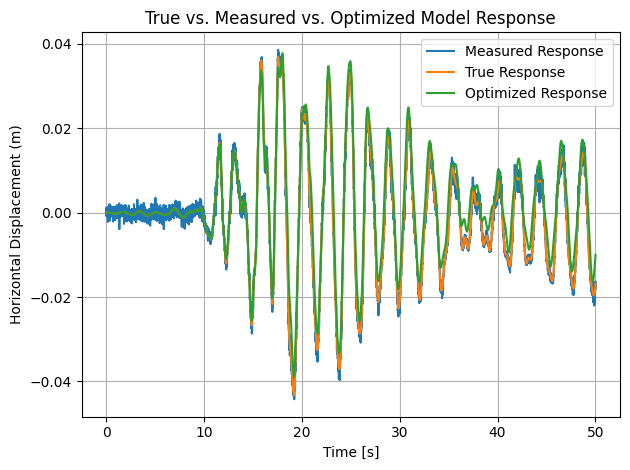

In [34]:
# Plot comparison between true and optimized responses
plt.figure()
plt.plot(time_record, y_measured, label='Measured Response')
plt.plot(time_record, y_true, label='True Response')
plt.plot(time_record, y_optimized, label='Optimized Response')
plt.xlabel('Time [s]')
plt.ylabel('Horizontal Displacement (m)')
plt.title('True vs. Measured vs. Optimized Model Response')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Bayesian Identification of Vibration Absorber Parameters in a 2-DOF Mechanical System Using Recursive Variational Inference

In [35]:
import numpy as np
import matplotlib.pyplot as plt

## Newmark-beta integrator for 2-DOF system

In [36]:
def simulate_2dof(theta, t, m1, m2, c1, k1, f_func,
                  beta=0.25, gamma=0.5):
    """
    Newmark-beta integration of a 2-DOF primary + absorber system.
    Equations: M x_ddot + C x_dot + K x = F(t)
    theta = {'k2': k2, 'c2': c2}
    Returns t, x1_array
    """
    dt = t[1] - t[0]
    n = t.size

    k2 = theta['k2']
    c2 = theta['c2']

    M = np.array([[m1, 0],
                  [0,  m2]])
    C = np.array([[c1 + c2,  -c2],
                  [ -c2,      c2]])
    K = np.array([[k1 + k2,  -k2],
                  [ -k2,       k2]])

    # forcing [f1; 0]
    F = np.zeros((n, 2))
    F[:, 0] = f_func(t)

    x = np.zeros((n, 2))
    v = np.zeros((n, 2))
    a = np.zeros((n, 2))

    # initial acceleration
    a[0] = np.linalg.solve(M, F[0] - C @ v[0] - K @ x[0])

    a0 = 1.0 / (beta * dt*dt)
    a1 = gamma / (beta * dt)
    a2 = 1.0 / (beta * dt)
    a3 = 1.0 / (2*beta) - 1.0
    a4 = gamma / beta - 1.0
    a5 = dt * (gamma / (2*beta) - 1.0)

    K_eff = K + a0*M + a1*C

    for i in range(n - 1):
        P_eff = (F[i+1]
                 + M @ (a0*x[i] + a2*v[i] + a3*a[i])
                 + C @ (a1*x[i] + a4*v[i] + a5*a[i]))
        x[i+1] = np.linalg.solve(K_eff, P_eff)
        a[i+1] = (a0*(x[i+1] - x[i])
                  - a2*v[i]
                  - a3*a[i])
        v[i+1] = (v[i]
                  + dt * ((1 - gamma)*a[i] + gamma*a[i+1]))

    return t, x[:, 0]

## Model wrapper

In [37]:
class FEModel2DOF:
    def __init__(self, t, m1, m2, c1, k1, f_func):
        self.t = t
        self.m1, self.m2 = m1, m2
        self.c1, self.k1 = c1, k1
        self.f_func = f_func

    def compute_response(self, theta):
        _, x1 = simulate_2dof(theta,
                              self.t,
                              self.m1, self.m2,
                              self.c1, self.k1,
                              self.f_func)
        return x1

    def compute_sensitivity(self, theta, eps=1e-4):
        keys = list(theta.keys())
        h0 = self.compute_response(theta)
        n = h0.size
        p = len(keys)
        C = np.zeros((n, p))
        for i, key in enumerate(keys):
            thp = theta.copy()
            thm = theta.copy()
            thp[key] += eps
            thm[key] -= eps
            hp = self.compute_response(thp)
            hm = self.compute_response(thm)
            C[:, i] = (hp - hm) / (2 * eps)
        return C

## True response + noise

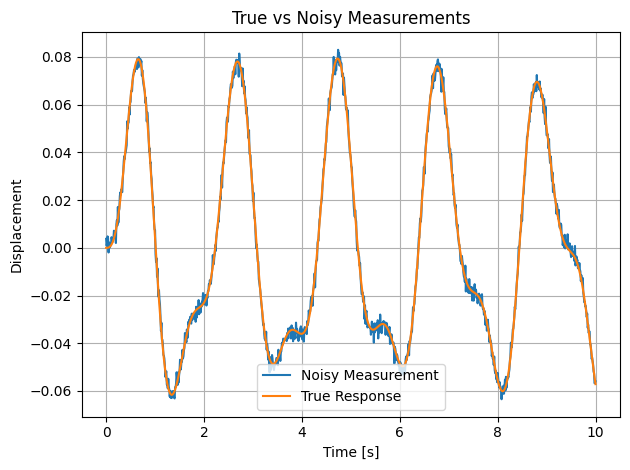

In [38]:
np.random.seed(0)
T, dt = 10.0, 0.01
t = np.arange(0, T+dt, dt)
F0, omega = 1.0, 2*np.pi  # 1 Hz sine
f_func = lambda tt: F0 * np.sin(omega*tt)

# Primary system
m1, m2 = 1.0, 0.1
c1, k1 = 0.02, 10.0
fe = FEModel2DOF(t, m1, m2, c1, k1, f_func)

# True absorber
theta_true = {'k2': 5.0, 'c2': 0.1}
_, y_true = simulate_2dof(theta_true, t, m1, m2, c1, k1, f_func)

noise_std = 0.05 * np.std(y_true)
y_meas = y_true + np.random.normal(0, noise_std, size=y_true.shape)

plt.figure()
plt.plot(t, y_meas, label='Noisy Measurement')
plt.plot(t, y_true, label='True Response')
plt.xlabel('Time [s]')
plt.ylabel('Displacement')
plt.title('True vs Noisy Measurements')
plt.legend(); plt.grid(True); plt.tight_layout()
plt.show()

## Variational Bayesian Estimator

In [39]:
import numpy as np
from scipy.linalg import inv, cholesky, solve_triangular

In [40]:
class VBEstimator:
    """
    Variational Bayesian estimator (adaptive) for model parameters and noise.
    Implements Eqs. (21), (25) from Nabiyan et al. (2023).  
    """
    def __init__(self, theta_init, P_init, mu_init, lambda_init, nu_init, V_init, Q, rho, rho_prime, ny, max_iter=2):
        # model parameters
        self.theta = np.array(list(theta_init.values()))          # (p,)
        self.P = P_init                                           # (p,p)
        # noise stats
        self.mu = mu_init                                         # (ny,)
        self.lambda_ = lambda_init                                # scalar
        self.nu = nu_init                                         # scalar
        self.V = V_init                                           # (ny,ny)
        # process noise covariance
        self.Q = Q                                                # (p,p)
        # forgetting factors
        self.rho = rho                                            
        self.rho_prime = rho_prime                                
        # dimensions
        self.ny = ny                                              
        self.p = self.theta.size
        self.max_iter = max_iter

    def predict_step(self):
        # Eq. (1) dynamics for parameters; forgetting for noise NIW priors
        self.theta_prior = self.theta.copy()
        self.P_prior = self.P + self.Q
        self.mu_prior = self.mu.copy()
        # NIW prior updates
        self.lambda_prior = self.rho_prime * self.lambda_
        self.nu_prior = self.rho * (self.nu - self.ny - 1) + self.ny + 1
        self.V_prior = self.rho * self.V

    def correct_step(self, yk, h_prior, C_prior):
        # yk: measurement at time k (ny,)
        # h_prior: predicted response vector at theta_prior (ny,)
        # C_prior: sensitivity at theta_prior (ny,p)
        # initialize
        theta_post = self.theta_prior.copy()
        # posterior noise cov estimate R_post using NIW mean: Eq. (18)
        R_post = self.V_prior / (self.nu_prior - self.ny - 1)
        mu_post = None

        for _ in range(self.max_iter):
            # Kalman gain: K = Pθy (Pyy)^-1
            Ptheta_y = self.P_prior @ C_prior.T                        # (p,ny)
            Pyy = C_prior @ self.P_prior @ C_prior.T + R_post         # (ny,ny)
            K = Ptheta_y @ inv(Pyy)                                   # (p,ny)
            # update theta
            theta_new = self.theta_prior + K @ (yk - h_prior - self.mu_prior)
            # update noise stats: Eq. (25-a,d) and NIW updates
            mu_new = (self.lambda_prior / (1 + self.lambda_prior)) * self.mu_prior \
                     + (1 / (1 + self.lambda_prior)) * (yk - h_prior)
            # V update: Eq. (25-d)
            term = (yk - h_prior - self.mu_prior)[:,None] @ (yk - h_prior - self.mu_prior)[None,:]
            V_new = self.V_prior + (self.lambda_prior / (1 + self.lambda_prior)) * term \
                    + C_prior @ self.P_prior @ C_prior.T
            R_new = V_new / (self.nu_prior + 1 - self.ny - 1)
            # convergence check
            if np.linalg.norm(theta_new - theta_post)/np.linalg.norm(theta_post) < 1e-2 \
               and np.linalg.norm(R_new - R_post)/np.linalg.norm(R_post) < 1e-2:
                mu_post = mu_new; R_post = R_new; theta_post = theta_new; break
            # otherwise iterate
            mu_post = mu_new; R_post = R_new; theta_post = theta_new

        # posterior updates: Eq. (21-b)
        P_post = self.P_prior - K @ Pyy @ K.T
        # assign posterior to state
        self.theta = theta_post
        self.P = P_post
        self.mu = mu_post
        self.V = V_new
        self.lambda_ = self.lambda_prior + 1
        self.nu = self.nu_prior + 1

## Recursive estimation

In [41]:
theta0   = {'k2':1.0, 'c2':1.0}
P0       = np.diag([1.0, 1.0])
mu0      = np.zeros(1)
lambda0, nu0 = 1.0, 2.1
V0       = (nu0 - 1 - 1) * np.eye(1) * noise_std**2
Q        = np.diag([1e-3, 1e-3])
rho, rho_p, ny = 0.95, 0.95, 1

vb = VBEstimator(theta0, P0, mu0, lambda0, nu0, V0,
                 Q, rho, rho_p, ny)

J_history = []
for k in range(len(t)):
    vb.predict_step()
    h_all = fe.compute_response(dict(zip(theta0.keys(), vb.theta_prior)))
    C_all = fe.compute_sensitivity(dict(zip(theta0.keys(), vb.theta_prior)))
    h_k = np.array([h_all[k]])
    C_k = C_all[k:k+1, :]
    resid = y_meas[k] - h_k - vb.mu_prior
    J_history.append((resid**2).item())
    vb.correct_step(np.array([y_meas[k]]), h_k, C_k)

## Plotting

### Plot cost evolution

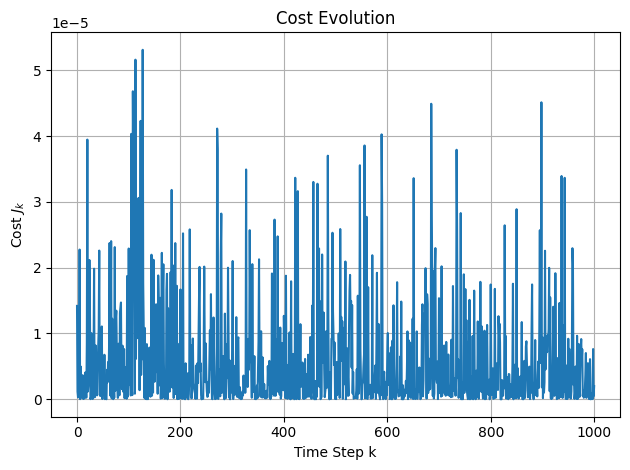

In [42]:
plt.figure()
plt.plot(J_history)
plt.xlabel('Time Step k')
plt.ylabel('Cost $J_k$')
plt.title('Cost Evolution')
plt.grid(True); plt.tight_layout()
plt.show()

### Optimized response vs true 

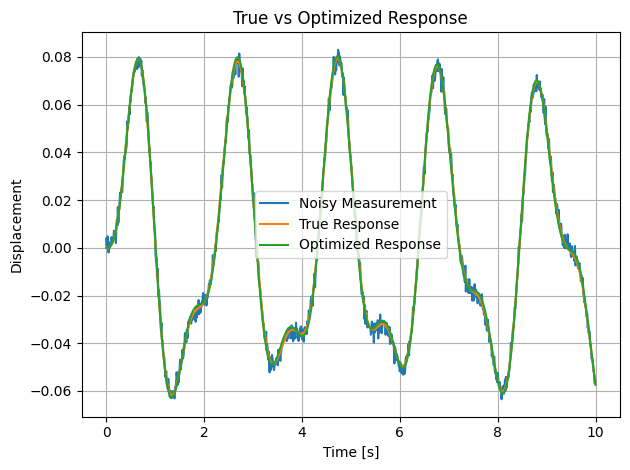

In [45]:
theta_opt = dict(zip(theta0.keys(), vb.theta))
_, y_opt = simulate_2dof(theta_opt, t, m1, m2, c1, k1, f_func)

plt.figure()
plt.plot(t, y_meas, label='Noisy Measurement')
plt.plot(t, y_true, label='True Response')
plt.plot(t, y_opt, label='Optimized Response')
plt.xlabel('Time [s]')
plt.ylabel('Displacement')
plt.title('True vs Optimized Response')
plt.legend(); plt.grid(True); plt.tight_layout()
plt.show()

### Final parameter estimates

In [44]:
print("Estimated k2:", theta_opt['k2'])
print("Estimated c2:", theta_opt['c2'])

Estimated k2: 5.025845909329553
Estimated c2: 0.14480143734155304
